## Regression MCQ

#### In this MCQ, we will engage in a comprehensive multiple-choice exercise, applying regression concepts and techniques to agricultural yield prediction. Through a series of challenges, we'll analyse variable relationships, feature engineering, model construction, and evaluation, enhancing our understanding and proficiency in regression analysis

### Learning Objectives
#### By the end of this notebook, you should be able to:
#### - Analyse predictor variables and their relationship with the target variable.
#### - Perform feature engineering tasks, including encoding categorical variables and scaling features.
#### - Construct and evaluate multiple linear regression models using appropriate libraries.
#### - Identify and address multicollinearity issues using regularisation techniques such as LASSO and Ridge regression.
#### - Interpret regression coefficients and understand their impact on the target variable.
#### - Implement decision tree models for prediction tasks, exploring both categorical and numerical data.
#### - Calculate and interpret MSE and RMSE for model evaluation

In [1]:
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import statsmodels.graphics.correlation as sgc
from statsmodels.graphics.gofplots import qqplot
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import OLSInfluence
import seaborn as sns

In [2]:
import re
import numpy as np
import pandas as pd
from field_data_processor import FieldDataProcessor
# from weather_data_processor import WeatherDataProcessor
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

config_params = {
    "sql_query": """
            SELECT *
            FROM geographic_features
            LEFT JOIN weather_features USING (FIELD_ID)
            LEFT JOIN soil_and_crop_features USING (FIELD_ID)
            LEFT JOIN farm_management_features USING (FIELD_ID)
    """,
    "db_path": 'sqlite:///Maji_Ndogo_farm_survey_small.db',
    "columns_to_rename": {'Annual_yield': 'Crop_type', 'Crop_type': 'Annual_yield'},
    "values_to_rename": {'cassaval': 'cassava', 'wheatn': 'wheat', 'teaa': 'tea'},
    "weather_csv_path": "https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Maji_Ndogo/Weather_station_data.csv",
    "weather_mapping_csv": "https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Maji_Ndogo/Weather_data_field_mapping.csv",
    "regex_patterns": {
        'Rainfall': r'(\d+(\.\d+)?)\s?mm',
        'Temperature': r'(\d+(\.\d+)?)\s?C',
        'Pollution_level': r'=\s*(-?\d+(\.\d+)?)|Pollution at \s*(-?\d+(\.\d+)?)'
    },
}

# ignoring the field data for now
field_processor = FieldDataProcessor(config_params)
field_processor.process()
field_df = field_processor.df

# We're not going to use the weather data this time, so we'll ignore it.
# weather_processor = WeatherDataProcessor(config_params)
# weather_processor.process()
# weather_df = weather_processor.weather_df

dataset = field_df.drop("Weather_station", axis=1)

2026-08-11 09:42:56,438 - data_ingestion - INFO - Database engine created successfully.
2026-08-11 09:42:56,593 - data_ingestion - INFO - Query executed successfully.
2026-08-11 09:42:56,593 - field_data_processor.FieldDataProcessor - INFO - Sucessfully loaded data.
2026-08-11 09:42:56,613 - field_data_processor.FieldDataProcessor - INFO - Swapped columns: Annual_yield with Crop_type
2026-08-11 09:42:57,471 - data_ingestion - INFO - CSV file read successfully from the web.


In [3]:
# validate the data
# !pip install pytest

dataset.to_csv('sampled_field_df.csv', index=False)

!pytest validate_data.py -v

import os
field_csv_path = 'sampled_field_df.csv'

# Delete sampled_field_df.csv if it exists
if os.path.exists(field_csv_path):
    os.remove(field_csv_path)
    print(f"Deleted {field_csv_path}")
else:
    print(f"{field_csv_path} does not exist.")

============================= test session starts =============================
platform win32 -- Python 3.7.1, pytest-7.1.2, pluggy-1.0.0 -- D:\Users\steph\anaconda3\envs\interactive_visuals_ALX\python.exe
cachedir: .pytest_cache
rootdir: D:\ALX\Data Science\Machine Learning\Random Forests and Applying Our Knowledge 11.0
collecting ... collected 4 items

validate_data.py::test_read_field_dataframe_shape PASSED                 [ 25%]
validate_data.py::test_field_dataframe_columns PASSED                    [ 50%]
validate_data.py::test_field_dataframe_non_negative_elevation PASSED     [ 75%]
validate_data.py::test_crop_types_are_valid PASSED                       [100%]

============================== 4 passed in 1.23s ==============================
Deleted sampled_field_df.csv


## Challenge 1: Understanding our variables and variable selection

### Question 1

#### How many predictors do we originally have in our dataset, and which of these are categorical in nature?

In [4]:
dataset.head()

,Field_ID,Elevation,Latitude,Longitude,Location,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,Soil_type,pH,Pollution_level,Plot_size,Annual_yield,Crop_type,Standard_yield
0,40734,786.05580,-7.389911,-7.556202,Rural_Akatsi,14.795113,1125.2,-3.1,33.1,15.00,0.62,Sandy,6.169393,0.085267,1.3,0.751354,cassava,0.577964
1,30629,674.33410,-7.736849,-1.051539,Rural_Sokoto,11.374611,1450.7,-3.9,30.6,13.35,0.64,Volcanic,5.676648,0.399684,2.2,1.069865,cassava,0.486302
2,39924,826.53390,-9.926616,0.115156,Rural_Sokoto,11.339692,2208.9,-1.8,28.4,13.30,0.69,Volcanic,5.331993,0.358029,3.4,2.208801,tea,0.649647
3,5754,574.94617,-2.420131,-6.592215,Rural_Kilimani,7.109855,328.8,-5.8,32.2,13.20,0.54,Loamy,5.328150,0.286687,2.4,1.277635,cassava,0.532348
4,14146,886.35300,-3.055434,-7.952609,Rural_Kilimani,55.007656,785.2,-2.5,31.0,14.25,0.72,Sandy,5.721234,0.043190,1.5,0.832614,wheat,0.555076


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5654 entries, 0 to 5653
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Field_ID           5654 non-null   int64  
 1   Elevation          5654 non-null   float64
 2   Latitude           5654 non-null   float64
 3   Longitude          5654 non-null   float64
 4   Location           5654 non-null   object 
 5   Slope              5654 non-null   float64
 6   Rainfall           5654 non-null   float64
 7   Min_temperature_C  5654 non-null   float64
 8   Max_temperature_C  5654 non-null   float64
 9   Ave_temps          5654 non-null   float64
 10  Soil_fertility     5654 non-null   float64
 11  Soil_type          5654 non-null   object 
 12  pH                 5654 non-null   float64
 13  Pollution_level    5654 non-null   float64
 14  Plot_size          5654 non-null   float64
 15  Annual_yield       5654 non-null   float64
 16  Crop_type          5654 

In [6]:
'''16 predictors with Location, Soil_type, and Crop_type being categorical'''

'16 predictors with Location, Soil_type, and Crop_type being categorical'

### Question 2

#### The categorical features in our dataset need to be converted into a format suitable for modeling. After applying dummy variable encoding to these categorical features, how many independent variables do we now have?

In [7]:
dataset.dtypes

Field_ID               int64
Elevation            float64
Latitude             float64
Longitude            float64
Location              object
Slope                float64
Rainfall             float64
Min_temperature_C    float64
Max_temperature_C    float64
Ave_temps            float64
Soil_fertility       float64
Soil_type             object
pH                   float64
Pollution_level      float64
Plot_size            float64
Annual_yield         float64
Crop_type             object
Standard_yield       float64
dtype: object

In [8]:
categorical_cols = dataset.select_dtypes(include=['object']).columns.tolist()

categorical_cols

['Location', 'Soil_type', 'Crop_type']

In [9]:
for col in categorical_cols:
    print(f'{col}: {dataset[col].unique().tolist()}')
#     print(dataset[col])

Location: ['Rural_Akatsi', 'Rural_Sokoto', 'Rural_Kilimani', 'Rural_Hawassa', 'Rural_Amanzi']
Soil_type: ['Sandy', 'Volcanic', 'Loamy', 'Silt', 'Peaty', 'Rocky']
Crop_type: ['cassava', 'tea', 'wheat', 'potato', 'banana', 'coffee', 'rice', 'maize']


In [10]:
df_encoded = pd.get_dummies(
    dataset,
    columns=categorical_cols,
    drop_first=True,
    dtype=float
)

df_encoded

,Field_ID,Elevation,Latitude,Longitude,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,...,Soil_type_Sandy,Soil_type_Silt,Soil_type_Volcanic,Crop_type_cassava,Crop_type_coffee,Crop_type_maize,Crop_type_potato,Crop_type_rice,Crop_type_tea,Crop_type_wheat
0,40734,786.05580,-7.389911,-7.556202,14.795113,1125.2,-3.1,33.1,15.00,0.62,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,30629,674.33410,-7.736849,-1.051539,11.374611,1450.7,-3.9,30.6,13.35,0.64,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,39924,826.53390,-9.926616,0.115156,11.339692,2208.9,-1.8,28.4,13.30,0.69,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,5754,574.94617,-2.420131,-6.592215,7.109855,328.8,-5.8,32.2,13.20,0.54,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,14146,886.35300,-3.055434,-7.952609,55.007656,785.2,-2.5,31.0,14.25,0.72,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5649,11472,681.36145,-7.358371,-6.254369,16.213196,885.7,-4.3,33.4,14.55,0.61,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5650,19660,667.02120,-3.154559,-4.475046,2.397553,501.1,-4.8,32.1,13.65,0.54,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5651,41296,670.77900,-14.472861,-6.110221,7.636470,1586.6,-3.8,33.4,14.80,0.64,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5652,33090,429.48840,-14.653089,-6.984116,13.944720,1272.2,-6.2,34.6,14.20,0.63,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
len(df_encoded.columns.tolist())

31

In [12]:
df_encoded.dtypes

Field_ID                     int64
Elevation                  float64
Latitude                   float64
Longitude                  float64
Slope                      float64
Rainfall                   float64
Min_temperature_C          float64
Max_temperature_C          float64
Ave_temps                  float64
Soil_fertility             float64
pH                         float64
Pollution_level            float64
Plot_size                  float64
Annual_yield               float64
Standard_yield             float64
Location_Rural_Amanzi      float64
Location_Rural_Hawassa     float64
Location_Rural_Kilimani    float64
Location_Rural_Sokoto      float64
Soil_type_Peaty            float64
Soil_type_Rocky            float64
Soil_type_Sandy            float64
Soil_type_Silt             float64
Soil_type_Volcanic         float64
Crop_type_cassava          float64
Crop_type_coffee           float64
Crop_type_maize            float64
Crop_type_potato           float64
Crop_type_rice      

### Question 3

#### From our encoded dataset, which variable has the third highest absolute correlation with the `Standard_yield`, excluding the variable itself?

In [13]:
df_encoded.corr()['Standard_yield'].abs().sort_values(ascending=False)

Standard_yield             1.000000
Crop_type_tea              0.432879
Soil_type_Volcanic         0.309982
Pollution_level            0.285761
Crop_type_coffee           0.222217
Annual_yield               0.220812
Location_Rural_Sokoto      0.212337
Soil_type_Silt             0.205861
pH                         0.196613
Crop_type_cassava          0.186716
Crop_type_potato           0.175484
Soil_type_Sandy            0.164714
Min_temperature_C          0.144233
Soil_type_Peaty            0.135509
Elevation                  0.129248
Max_temperature_C          0.111649
Location_Rural_Hawassa     0.110623
Crop_type_rice             0.104056
Crop_type_wheat            0.092420
Longitude                  0.085343
Soil_type_Rocky            0.078355
Soil_fertility             0.070205
Latitude                   0.061724
Slope                      0.056991
Rainfall                   0.039217
Location_Rural_Amanzi      0.032049
Field_ID                   0.030802
Plot_size                  0

### Question 4

#### In order to fit an ordinary least squares regression model to our encoded data we would need to make sure that all our variables are numeric. Through dummy variable encoding, we converted our categorical variables to multiple int/boolean variables (depending on the environment you are worling on). The `sm.OLS()` method itself does not inherently handle boolean data types implicitly.

#### In most cases, when fitting a model with sm.OLS(), it's essential to ensure that all features are numeric. If boolean columns are present, they should be explictly converted to numeric types before fitting the model. 

#### Suppose our columns converted to boolean datatypes, which of the following statements is true after converting the boolean columns in the dataset to integer datatype?
#### - The boolean columns have been replaced with binary integer representations, with True converted to 1 and False converted to 0.
#### - The boolean columns have been removed from the dataset.
#### - The boolean columns have been replaced with binary integer representations, with True converted to 0 and False converted to 1.
#### - The boolean columns have been converted to a unique string datatype that is also an integer.

In [14]:
'''The boolean columns have been replaced with binary integer representations, with True converted to 1 and False converted to 0.'''

'The boolean columns have been replaced with binary integer representations, with True converted to 1 and False converted to 0.'

### Question 5

#### Suppose we wish to determine which of the predictors in our dataset are statistically significant. We will follow the following steps:
#### - Fit a statsmodels regression model to predict `Standard_yield` using our encoded dataset
#### Extract p-values for each predictor from the vitted model to find the ones that are significant based on a given threshold.

#### Which of the following variables do we find to be statistically significant for predicting `Standard_yield`, based on a p-value threshold of 0.05 (p-value < 0.05) ?

In [15]:
import statsmodels.api as sm
import pandas as pd

In [16]:
df_encoded.columns.tolist()

['Field_ID',
 'Elevation',
 'Latitude',
 'Longitude',
 'Slope',
 'Rainfall',
 'Min_temperature_C',
 'Max_temperature_C',
 'Ave_temps',
 'Soil_fertility',
 'pH',
 'Pollution_level',
 'Plot_size',
 'Annual_yield',
 'Standard_yield',
 'Location_Rural_Amanzi',
 'Location_Rural_Hawassa',
 'Location_Rural_Kilimani',
 'Location_Rural_Sokoto',
 'Soil_type_Peaty',
 'Soil_type_Rocky',
 'Soil_type_Sandy',
 'Soil_type_Silt',
 'Soil_type_Volcanic',
 'Crop_type_cassava',
 'Crop_type_coffee',
 'Crop_type_maize',
 'Crop_type_potato',
 'Crop_type_rice',
 'Crop_type_tea',
 'Crop_type_wheat']

In [17]:
X = df_encoded.drop(['Standard_yield', 'Field_ID'], axis=1)
y = df_encoded['Standard_yield']

In [18]:
X = sm.add_constant(X)

In [19]:
model = sm.OLS(y, X)

results = model.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Standard_yield   R-squared:                       0.756
Model:                            OLS   Adj. R-squared:                  0.755
Method:                 Least Squares   F-statistic:                     623.8
Date:                Tue, 11 Aug 2026   Prob (F-statistic):               0.00
Time:                        09:43:51   Log-Likelihood:                 8358.2
No. Observations:                5654   AIC:                        -1.666e+04
Df Residuals:                    5625   BIC:                        -1.647e+04
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       0.6982      0.183      3.806      0.000       0.339       1.058
Elevation               -6.517e-05      0.000     -0.628      0.530      -0.000       0.000
Latitude                   -0.0023      0.001     -3.372      0.001      -0.004      -0.001
Longitude                  -0.0014      0.001     -2.088      0.037      -0.003   -8.32e-05
Slope                       0.0014      0.001      1.769      0.077      -0.000       0.003
Rainfall                  4.27e-05   2.24e-05      1.906      0.057   -1.21e-06    8.66e-05
Min_temperature_C           0.0121      0.010      1.273      0.203      -0.007       0.031
Max_temperature_C          -0.0026      0.002     -1.328      0.184      -0.006       0.001
Ave_temps                   0.0048      0.004      1.250      0.211      -0.003       0.012
Soil_fertility             -0.3560      0.257     -1.383      0.167      -0.861       0.149
pH                          0.0206      0.001     14.509      0.000       0.018       0.023
Pollution_level            -0.1665      0.005    -35.319      0.000      -0.176      -0.157
Plot_size                  -0.0429      0.001    -50.411      0.000      -0.045      -0.041
Annual_yield                0.0811      0.002     53.269      0.000       0.078       0.084
Location_Rural_Amanzi       0.0062      0.005      1.325      0.185      -0.003       0.015
Location_Rural_Hawassa     -0.0001      0.003     -0.040      0.968      -0.007       0.007
Location_Rural_Kilimani     0.0128      0.004      3.111      0.002       0.005       0.021
Location_Rural_Sokoto       0.0355      0.005      7.570      0.000       0.026       0.045
Soil_type_Peaty            -0.0963      0.006    -16.784      0.000      -0.108      -0.085
Soil_type_Rocky            -0.1022      0.005    -19.741      0.000      -0.112      -0.092
Soil_type_Sandy            -0.0744      0.003    -23.917      0.000      -0.081      -0.068
Soil_type_Silt             -0.1178      0.005    -25.492      0.000      -0.127      -0.109
Soil_type_Volcanic         -0.0534      0.004    -12.605      0.000      -0.062      -0.045
Crop_type_cassava           0.0344      0.003      9.842      0.000       0.028       0.041
Crop_type_coffee           -0.0029      0.003     -0.891      0.373      -0.009       0.004
Crop_type_maize             0.0505      0.004     11.792      0.000       0.042       0.059
Crop_type_potato            0.0998      0.004     26.015      0.000       0.092       0.107
Crop_type_rice              0.1011      0.004     23.605      0.000       0.093       0.110
Crop_type_tea               0.1162      0.004     31.166      0.000       0.109       0.123
Crop_type_wheat             0.0468      0.003     15.040      0.000       0.041       0.053
===============================================

In [20]:
alpha = 0.05

p_values = results.pvalues.drop('const')

significant_p_values = p_values[p_values < alpha]

max(significant_p_values.index)

'pH'

## Challenge 2: Generating a multiple linear regression model

### Question 6

#### Create a correlation matrix using all the columns in our encoded dataset and display it as a heatmap.

In [21]:
df_encoded.columns.tolist()

['Field_ID',
 'Elevation',
 'Latitude',
 'Longitude',
 'Slope',
 'Rainfall',
 'Min_temperature_C',
 'Max_temperature_C',
 'Ave_temps',
 'Soil_fertility',
 'pH',
 'Pollution_level',
 'Plot_size',
 'Annual_yield',
 'Standard_yield',
 'Location_Rural_Amanzi',
 'Location_Rural_Hawassa',
 'Location_Rural_Kilimani',
 'Location_Rural_Sokoto',
 'Soil_type_Peaty',
 'Soil_type_Rocky',
 'Soil_type_Sandy',
 'Soil_type_Silt',
 'Soil_type_Volcanic',
 'Crop_type_cassava',
 'Crop_type_coffee',
 'Crop_type_maize',
 'Crop_type_potato',
 'Crop_type_rice',
 'Crop_type_tea',
 'Crop_type_wheat']

In [22]:
correlation = df_encoded.corr().drop('Field_ID', axis=1)

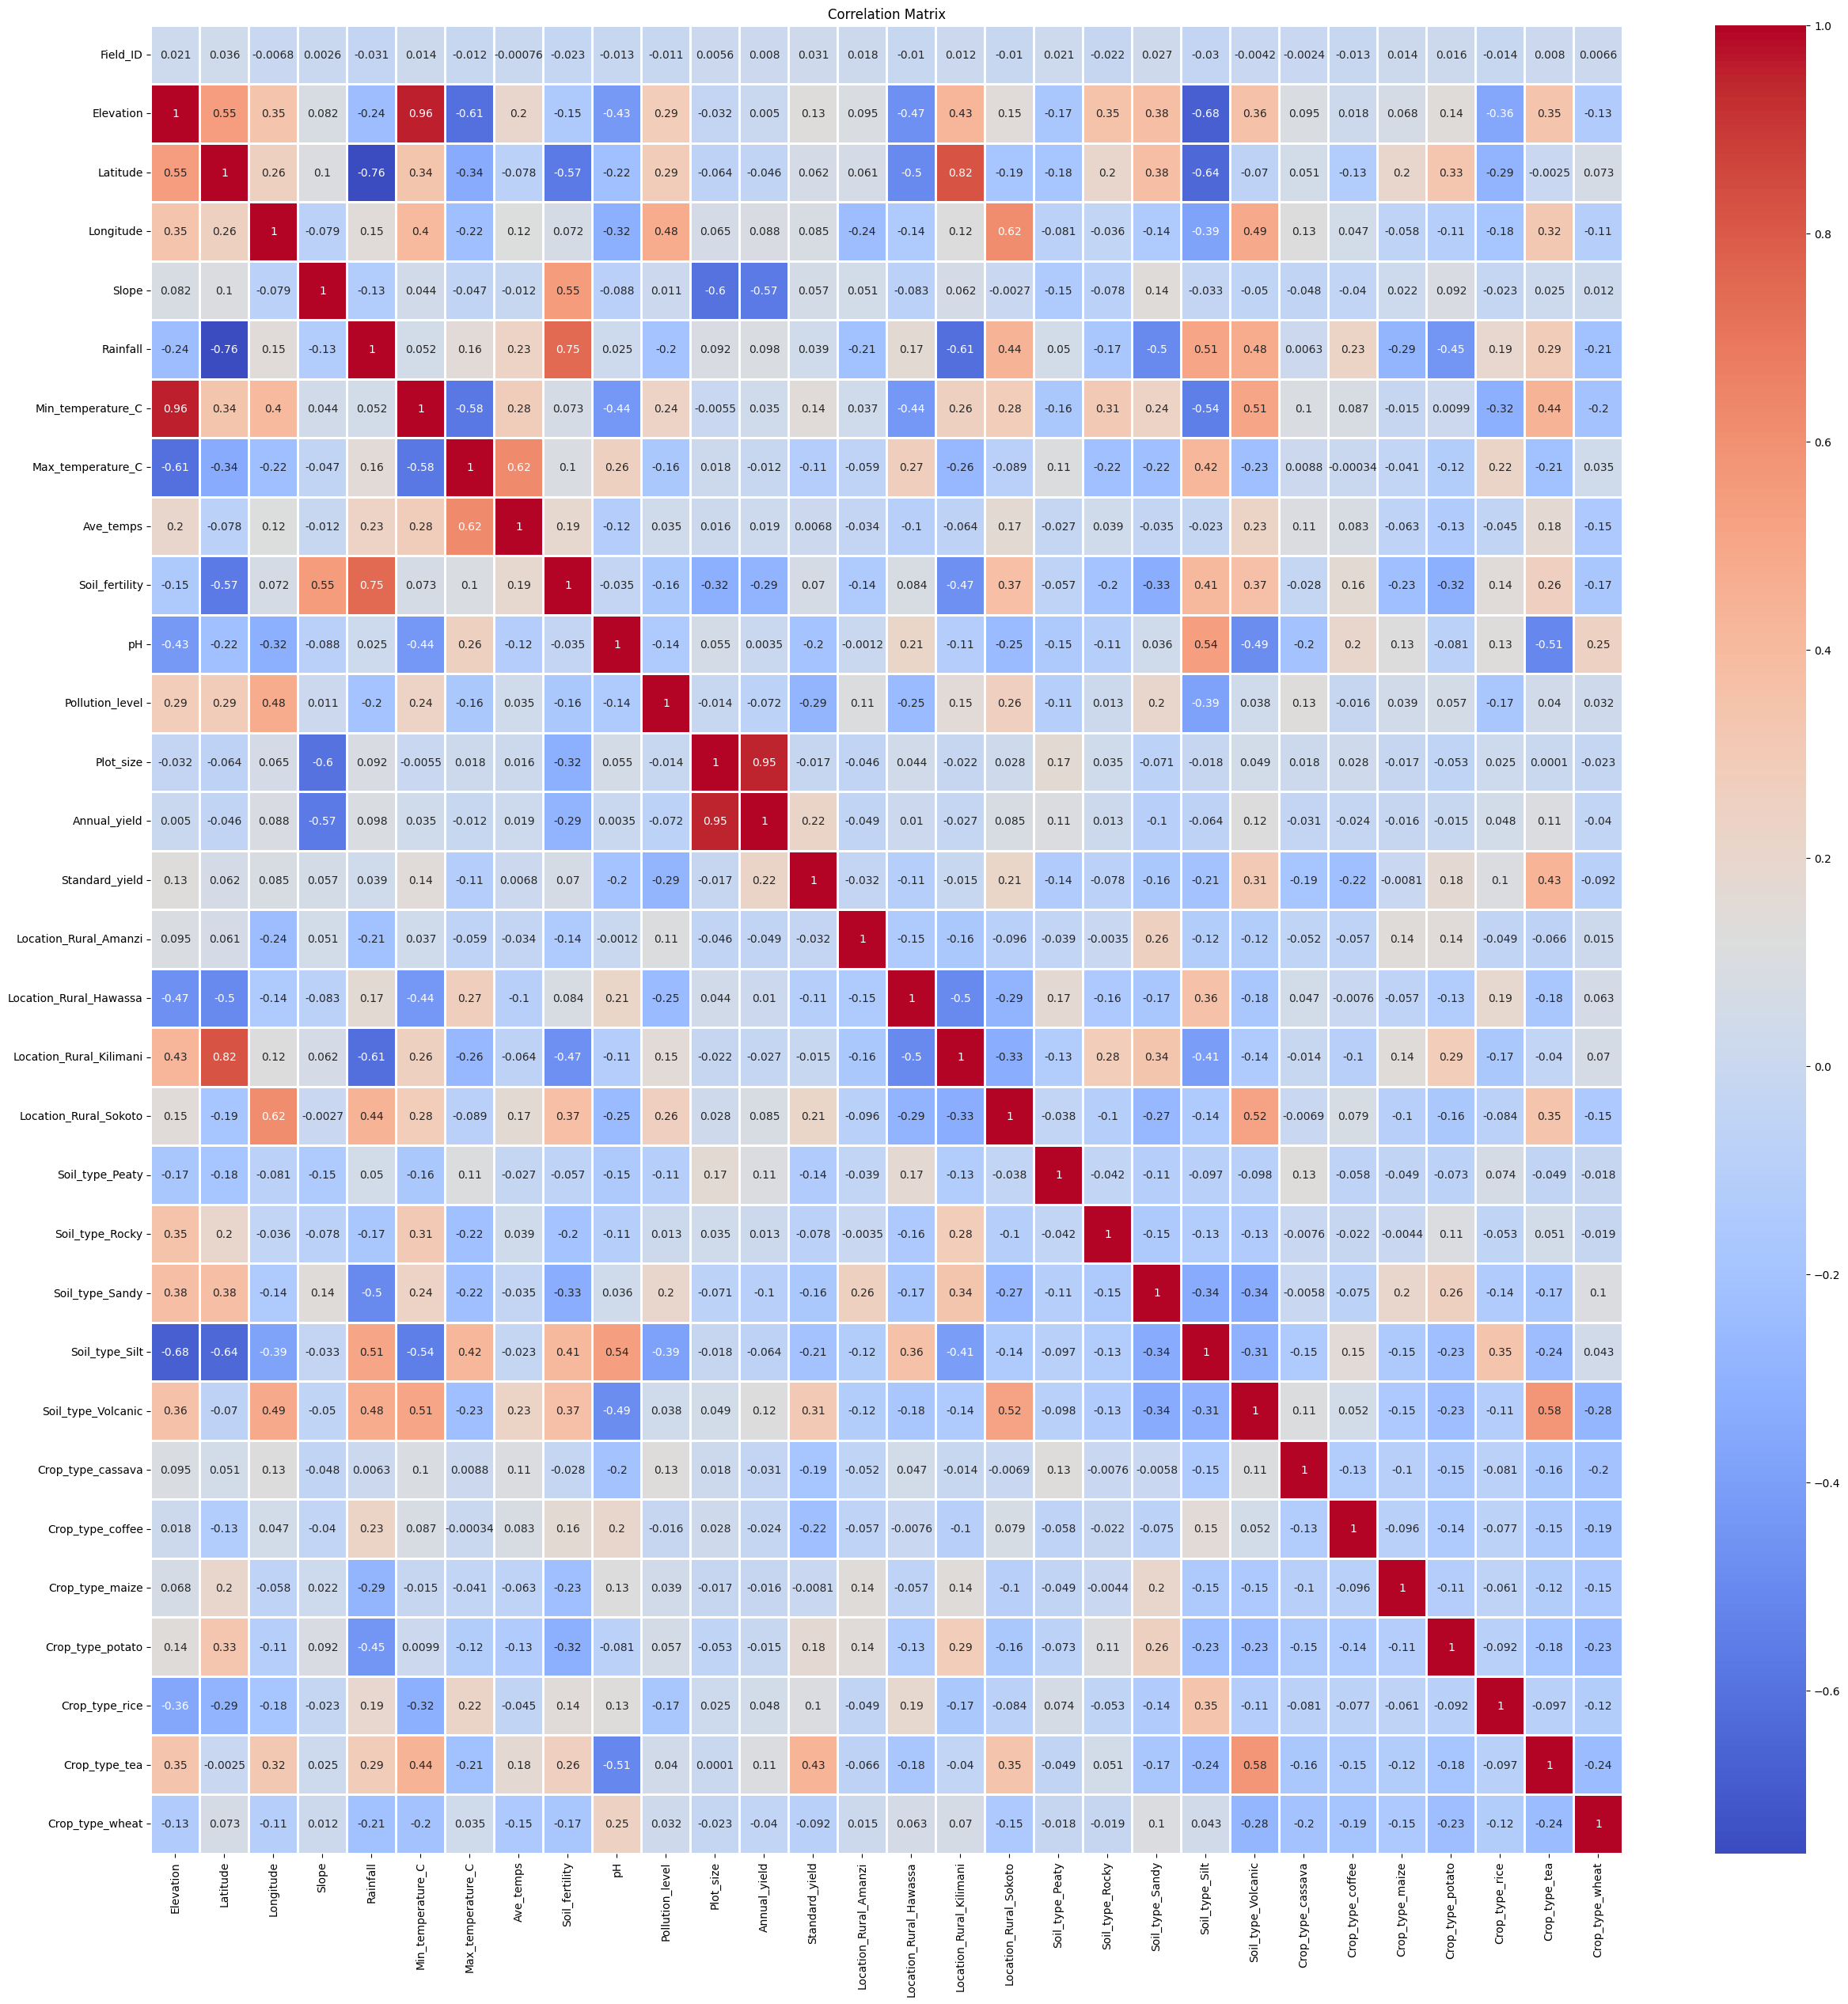

In [28]:
plt.figure(figsize=(30,30))

sns.heatmap(correlation, annot=True, cmap='coolwarm', linewidths=1.0)

plt.title('Correlation Matrix')
plt.show()

In [29]:
'''Min_temperature_C and Elevation have a strong positive correlation of 0.96'''

'Min_temperature_C and Elevation have a strong positive correlation of 0.96'

### Question 7

#### Now that we have analyzed our variables, let's fit an ordinary least squares regression model using `statsmodels.formula.api` and then print the model summary. Construct the model using all the independent variables in our encoded dataset (excluding `Field_ID`)

#### Which of the following statements accurately describes the interpretation of the F-statistic in the contest of our regression model?
#### - The F-statistic tests the overall significance of the regression model. A low F-statistic value with a corresponding high p-value indicates that the regression model is statistically significant, meaning that at least one of the independent variables has a significant effect on the dependent variable.
#### - The F-statistic tests the overall significance of the regression model. A high F-statistic value with a corresponding low p-value indicates that the regression model is statistically significant, meaning that at least one of the independent variables has a significant effect on the dependent variable.
#### - The F-statistic tests the overall significance of the regression model. A high F-statistic value with a corresponding high p-value indicates that the regression model is statistically significant, meaning that at least one of the independent variables has a significant effect on the dependent variable.
#### - The F-statistic tests the overall significance of the regression model. A low F-statistic value with a corresponding low p-value indicates that the regression model is not statistically significant., meaning that none of the independent variables have a significant effect on the dependent variable.

In [32]:
df_encoded.columns.tolist()

['Field_ID',
 'Elevation',
 'Latitude',
 'Longitude',
 'Slope',
 'Rainfall',
 'Min_temperature_C',
 'Max_temperature_C',
 'Ave_temps',
 'Soil_fertility',
 'pH',
 'Pollution_level',
 'Plot_size',
 'Annual_yield',
 'Standard_yield',
 'Location_Rural_Amanzi',
 'Location_Rural_Hawassa',
 'Location_Rural_Kilimani',
 'Location_Rural_Sokoto',
 'Soil_type_Peaty',
 'Soil_type_Rocky',
 'Soil_type_Sandy',
 'Soil_type_Silt',
 'Soil_type_Volcanic',
 'Crop_type_cassava',
 'Crop_type_coffee',
 'Crop_type_maize',
 'Crop_type_potato',
 'Crop_type_rice',
 'Crop_type_tea',
 'Crop_type_wheat']

In [43]:
exclude = ['Standard_yield', 'Field_ID']

predictors = [col for col in df_encoded.columns if col not in exclude]

# print(predictors)

# 'Standard_yield' in predictors

formula = 'Standard_yield ~ ' + ' + '.join(predictors)

# print(formula)

model = smf.ols(formula=formula, data=df_encoded)

ols_results = model.fit()

ols_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Standard_yield   R-squared:                       0.756
Model:                            OLS   Adj. R-squared:                  0.755
Method:                 Least Squares   F-statistic:                     623.8
Date:                Tue, 11 Aug 2026   Prob (F-statistic):               0.00
Time:                        10:25:27   Log-Likelihood:                 8358.2
No. Observations:                5654   AIC:                        -1.666e+04
Df Residuals:                    5625   BIC:                        -1.647e+04
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   0.6982      0.183      3.806      0.000       0.339       1.058
Elevation               -6.517e-05      0.000     -0.628      0.530      -0.000       0.000
Latitude                   -0.0023      0.001     -3.372      0.001      -0.004      -0.001
Longitude                  -0.0014      0.001     -2.088      0.037      -0.003   -8.32e-05
Slope                       0.0014      0.001      1.769      0.077      -0.000       0.003
Rainfall                  4.27e-05   2.24e-05      1.906      0.057   -1.21e-06    8.66e-05
Min_temperature_C           0.0121      0.010      1.273      0.203      -0.007       0.031
Max_temperature_C          -0.0026      0.002     -1.328      0.184      -0.006       0.001
Ave_temps                   0.0048      0.004      1.250      0.211      -0.003       0.012
Soil_fertility             -0.3560      0.257     -1.383      0.167      -0.861       0.149
pH                          0.0206      0.001     14.509      0.000       0.018       0.023
Pollution_level            -0.1665      0.005    -35.319      0.000      -0.176      -0.157
Plot_size                  -0.0429      0.001    -50.411      0.000      -0.045      -0.041
Annual_yield                0.0811      0.002     53.269      0.000       0.078       0.084
Location_Rural_Amanzi       0.0062      0.005      1.325      0.185      -0.003       0.015
Location_Rural_Hawassa     -0.0001      0.003     -0.040      0.968      -0.007       0.007
Location_Rural_Kilimani     0.0128      0.004      3.111      0.002       0.005       0.021
Location_Rural_Sokoto       0.0355      0.005      7.570      0.000       0.026       0.045
Soil_type_Peaty            -0.0963      0.006    -16.784      0.000      -0.108      -0.085
Soil_type_Rocky            -0.1022      0.005    -19.741      0.000      -0.112      -0.092
Soil_type_Sandy            -0.0744      0.003    -23.917      0.000      -0.081      -0.068
Soil_type_Silt             -0.1178      0.005    -25.492      0.000      -0.127      -0.109
Soil_type_Volcanic         -0.0534      0.004    -12.605      0.000      -0.062      -0.045
Crop_type_cassava           0.0344      0.003      9.842      0.000       0.028       0.041
Crop_type_coffee           -0.0029      0.003     -0.891      0.373      -0.009       0.004
Crop_type_maize             0.0505      0.004     11.792      0.000       0.042       0.059
Crop_type_potato            0.0998      0.004     26.015      0.000       0.092       0.107
Crop_type_rice              0.1011      0.004     23.605      0.000       0.093       0.110
Crop_type_tea               0.1162      0.004     31.166      0.000       0.109       0.123
Crop_type_wheat             0.0468      0.003     15.040      0.000       0.041       0.053
===============================================

In [44]:
'''The F-statistic tests the overall significance of the regression model. A high F-statistic value with a corresponding high p-value indicates that the regression model is statistically significant, meaning that at least one of the independent variables has a significant effect on the dependent variable.'''

'The F-statistic tests the overall significance of the regression model. A high F-statistic value with a corresponding high p-value indicates that the regression model is statistically significant, meaning that at least one of the independent variables has a significant effect on the dependent variable.'

### Question 8

#### This summary gives us an indication of possible multicolinearity present within our predictor variables. The presence of any correlation among predictors is detrimental to model quality because it tends to increase the standard error of the coefficients and it becomes difficult to estimate the effect of any one predictor variable on the response variable.

#### To avoid this, let's reduce the number of independent variables included in our model. Fit the model using the following variables:
#### - `Pollution_level`
#### - `Crop_type_coffee`
#### - `Crop_type_tea`
#### - `Location_Rural_Sokoto`
#### - `Annual_yield`
#### - `Soil_type_Silt`
#### - `Soil_type_Volcanic`

#### After reducing the number of dependent variables accordingly, how did the model change?

In [46]:
refined_predictors = [
    'Pollution_level', 'Crop_type_coffee', 'Crop_type_tea',
    'Location_Rural_Sokoto', 'Annual_Yield', 'Soil_type_Silt',
    'Soil_type_Volcanic'
]

refined_formula = 'Standard_yield ~ ' + ' + '.join(refined_predictors)

# print(refined_formula)

refined_model = smf.ols(formula, data=df_encoded)

refined_ols_results = refined_model.fit()

refined_ols_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Standard_yield   R-squared:                       0.756
Model:                            OLS   Adj. R-squared:                  0.755
Method:                 Least Squares   F-statistic:                     623.8
Date:                Tue, 11 Aug 2026   Prob (F-statistic):               0.00
Time:                        20:10:07   Log-Likelihood:                 8358.2
No. Observations:                5654   AIC:                        -1.666e+04
Df Residuals:                    5625   BIC:                        -1.647e+04
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   0.6982      0.183      3.806      0.000       0.339       1.058
Elevation               -6.517e-05      0.000     -0.628      0.530      -0.000       0.000
Latitude                   -0.0023      0.001     -3.372      0.001      -0.004      -0.001
Longitude                  -0.0014      0.001     -2.088      0.037      -0.003   -8.32e-05
Slope                       0.0014      0.001      1.769      0.077      -0.000       0.003
Rainfall                  4.27e-05   2.24e-05      1.906      0.057   -1.21e-06    8.66e-05
Min_temperature_C           0.0121      0.010      1.273      0.203      -0.007       0.031
Max_temperature_C          -0.0026      0.002     -1.328      0.184      -0.006       0.001
Ave_temps                   0.0048      0.004      1.250      0.211      -0.003       0.012
Soil_fertility             -0.3560      0.257     -1.383      0.167      -0.861       0.149
pH                          0.0206      0.001     14.509      0.000       0.018       0.023
Pollution_level            -0.1665      0.005    -35.319      0.000      -0.176      -0.157
Plot_size                  -0.0429      0.001    -50.411      0.000      -0.045      -0.041
Annual_yield                0.0811      0.002     53.269      0.000       0.078       0.084
Location_Rural_Amanzi       0.0062      0.005      1.325      0.185      -0.003       0.015
Location_Rural_Hawassa     -0.0001      0.003     -0.040      0.968      -0.007       0.007
Location_Rural_Kilimani     0.0128      0.004      3.111      0.002       0.005       0.021
Location_Rural_Sokoto       0.0355      0.005      7.570      0.000       0.026       0.045
Soil_type_Peaty            -0.0963      0.006    -16.784      0.000      -0.108      -0.085
Soil_type_Rocky            -0.1022      0.005    -19.741      0.000      -0.112      -0.092
Soil_type_Sandy            -0.0744      0.003    -23.917      0.000      -0.081      -0.068
Soil_type_Silt             -0.1178      0.005    -25.492      0.000      -0.127      -0.109
Soil_type_Volcanic         -0.0534      0.004    -12.605      0.000      -0.062      -0.045
Crop_type_cassava           0.0344      0.003      9.842      0.000       0.028       0.041
Crop_type_coffee           -0.0029      0.003     -0.891      0.373      -0.009       0.004
Crop_type_maize             0.0505      0.004     11.792      0.000       0.042       0.059
Crop_type_potato            0.0998      0.004     26.015      0.000       0.092       0.107
Crop_type_rice              0.1011      0.004     23.605      0.000       0.093       0.110
Crop_type_tea               0.1162      0.004     31.166      0.000       0.109       0.123
Crop_type_wheat             0.0468      0.003     15.040      0.000       0.041       0.053
===============================================

In [47]:
'''The model remained unchanged'''

'The model remained unchanged'

### Question 9

#### Let's evaluate our model's results. Generate a scatter plot of the residuals against the fitted values allowing us to visually inspect whether the residuals have constant variance and are distributed randomly around the zero residual line.

#### What does the scatter plot tell us?

In [48]:
refined_ols_results.fittedvalues

0       0.549734
1       0.520959
2       0.682314
3       0.527191
4       0.570980
          ...   
5649    0.545794
5650    0.435515
5651    0.705615
5652    0.496056
5653    0.494325
Length: 5654, dtype: float64

In [49]:
refined_ols_results.resid

0       0.028230
1      -0.034657
2      -0.032666
3       0.005157
4      -0.015904
          ...   
5649    0.008688
5650    0.002679
5651    0.095161
5652    0.011540
5653   -0.041261
Length: 5654, dtype: float64

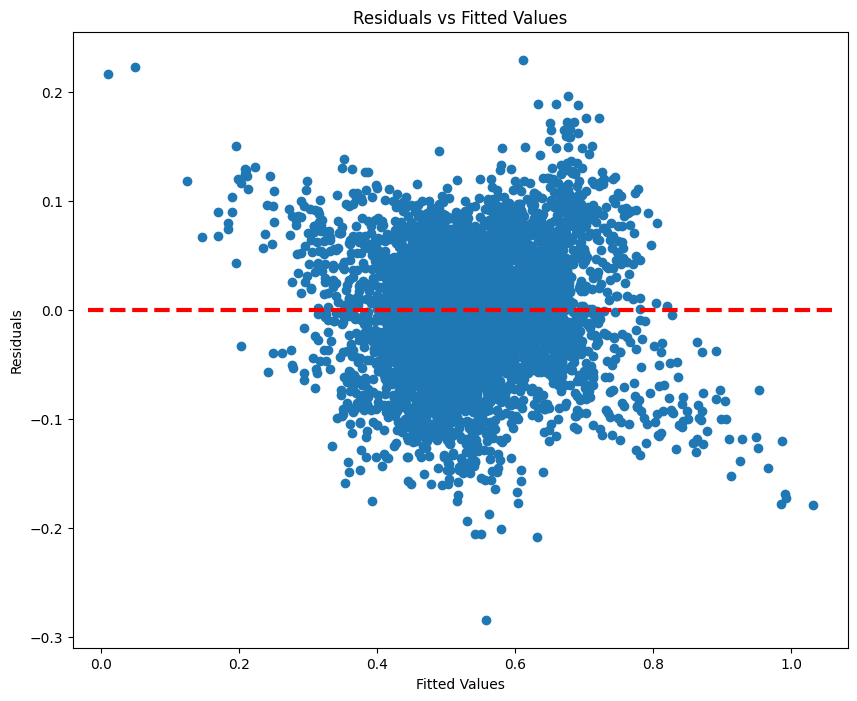

In [65]:
plt.figure(figsize=(10,8))

plt.scatter(refined_ols_results.fittedvalues, refined_ols_results.resid)

plt.axhline(
    y=0,
    linestyle='--',
    linewidth=3,
    color='red',
    xmin=0.02,
    xmax=0.98
)

plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')

plt.show()

In [67]:
'''The plot indicates homoskedasticity as residuals have a constant variance and are distributed randomly around the zero redisual line'''

'The plot indicates homoskedasticity as residuals have a constant variance and are distributed randomly around the zero redisual line'

### Question 10

#### If a linear regression model indicated heteroscedasticity, which of the following actions could be considered to address this issue?

#### - Applying transformations to the independent variable to better fir the linear relationship.
#### - Implementing weighted least squares regression to give less emphasis to observations with higher variance in residuals.
#### - Removing outliers from the dataset to reduce the impact of extreme values on the variance of residuals.
#### - All of the above

In [68]:
'''All of the above'''

'All of the above'

### Challenge 3: Using regularisation to optimise agricultural yield

#### Continuting with our task, after fitting our model, we decide to go back to the drawing board to explore more ways to implement feature engineering and data pre-processing in order to optimise our model. We supsect that, if we use all the variables available to us, the model might overfit due to the high dimensionality of the data. Regularisation techniques will therefore be critical in building a predictive model that generalises well to new, unseen data.

### Question 11

#### Our first step in the feature engineering involves creating a new feature `Temperature_Range` and scaling features using `StandardScaler`. The difference between `Min_temperature_C` and `Max_temperature_C` is the temperature range.

#### Given the code block below, which option correctly completes the feature engineering step of creating the `Temperature_Range` column?

In [71]:
from sklearn.preprocessing import StandardScaler

dataset['Temperature_Range'] = dataset['Max_temperature_C'] - dataset['Min_temperature_C']

# Select features for scaling (exclude non-numeric or target variables)
features = [
    'Elevation', 'Slope', 'Rainfall', 'Ave_temps',
    'Temperature_Range', 'Soil_fertility', 'pH',
    'Pollution_level'
]

# Initialise StandardScaler and apply it to the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(dataset[features])

# print(type(scaled_features))

# Show the first 5 rows of the scaled features
print(scaled_features[:5])

[[ 0.85426539  0.31997088 -0.15356676  2.21747303  0.30626766  0.01544079
   0.71256827 -0.61634976]
 [ 0.21055364 -0.03858151  0.49777372  0.15900087 -0.25298298  0.4619994
   0.08816394  0.7886906 ]
 [ 1.08748981 -0.04224188  2.01496684  0.09662293 -1.66755812  1.57839593
  -0.34858051  0.60254524]
 [-0.3620941  -0.4856324  -1.74719984 -0.02813296  0.8984154  -1.77079366
  -0.35345077  0.28374058]
 [ 1.43215211  4.53523034 -0.83392242  1.28180387 -0.58195394  2.24823384
   0.14466333 -0.80437805]]


### Question 12

#### Consider a scenario where we decide to employ LASSO regression to identify predictive features associated with our dependent variable. We implement the Pytohn code block provided below.

#### What is the purpose of the `LassoCV(cv=5)` constructor parameter `cv=5`?

In [73]:
from sklearn.linear_model import LassoCV

# scaled_features is our matrix of scaled features and dataset['Standard_yield'] is the target variable
lasso = LassoCV(cv=5).fit(scaled_features, dataset['Standard_yield'])

# Find the features with non-zero coefficients
selected_features = [features[i] for i, coef in enumerate(lasso.coef_) if coef != 0]

In [74]:
'''It indicates that 5-fold cross-validation should be used to select the best regularisation parameter'''

'It indicates that 5-fold cross-validation should be used to select the best regularisation parameter'

### Question 13

#### In trying to address multicollinearity in our dataset, we also decide to implement Ridge regression. After understanding that Ridge regression applies an L2 penalty to the coefficients to reduce their magnitue without setting them to zero, we decide to use `RidgeCV` for applying Ridge regression with cross-validation to select the optimal penalty strength. Given the snippet of code below, which parameter correctly adjusts teh strength of the regularisation applied to the model?

In [75]:
from sklearn.linear_model import RidgeCV

# Insert selected option here
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

# Apply Ridge regression with cross-validation
ridge = RidgeCV(alphas=alphas, cv=5).fit(scaled_features, dataset['Standard_yield'])

### Question 14

#### Given our dataset includes variables such as `Elevation` and `Slope`, and considering the potential interactions between these variables might impact crop yield, we aim to capture both these interactions and possible non-linear relationships. Which of the following methods is specifically designed to create a quadratic interaction term without including an intercept in the feature set?

In [76]:
from sklearn.preprocessing import PolynomialFeatures

# Generate plynomial and interaction features
# Insert selected option here
poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features = poly.fit_transform(dataset[['Elevation', 'Slope']])

# Display the shape of the new feature matrix
poly_features.shape

(5654, 5)

### Question 15

#### After implementing Ridge regression to address multicolinearity and prevent overfitting in our model we need to interpret the coefficients to understand the impact of each feature on the standard yield.

#### Based on the output of the Ridge regression coefficients in the code block below, which statement is true regarding the impact of each feature on the standard yield?

In [77]:
from sklearn.linear_model import Ridge
import numpy as np

# Assuming `X` is the feature matrix and `y` is the target variable
X = np.array([[0.5, 0.2, 0.1],
              [0.9, 0.3, 0.5],
              [0.3, 0.8, 0.2]
             ])

y = np.array([0.7, 0.6, 0.8])

# Fit Ridge regression model with alpha=0.1
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X, y)

# Display the coefficients of the model
ridge_model.coef_

array([-0.13661379,  0.10262221, -0.07348657])

### Challenge 4: Making a prediction using decision trees

#### After learning that decision trees are easy to implement and are capable of handling both categorical and numerical data while being resilient to outliers, we decide to implement a decision tree on our encoded dataset

### Question 16

#### Train a decision tree with the following specifications:
#### - Using our **previously encoded dataset**, split the data into dependent and independent variables using all the features except for `Standard_yield` and `Field_ID` as independent variables.
#### - Split the data into training and testing data.
#### - Use the `DecisionTreeRegressor` to fit a model using a `max_depth` of 2 and a `random_state` of 42

#### Using the trained Decision Tree Regressor model, make a prediction for y given the following x-values:
`[864.66138, -8.12890218821531, -8.311822719284072, 16.274624300000003, 1237.7200000000003, -3.4100000000000006, 36.410000000000004, 16.5,0.682, 6.7863323423108195, 0.09379352739936421, 1.4300000000000002, 0.8264890400277934,0.0,0.0,0.0,0.0,0.0,0.0,1.1,0.0,0.0,1.1,0.0, 0.0,0.0,0.0,0.0,0.0]`

In [81]:
df_encoded.columns.tolist()

['Field_ID',
 'Elevation',
 'Latitude',
 'Longitude',
 'Slope',
 'Rainfall',
 'Min_temperature_C',
 'Max_temperature_C',
 'Ave_temps',
 'Soil_fertility',
 'pH',
 'Pollution_level',
 'Plot_size',
 'Annual_yield',
 'Standard_yield',
 'Location_Rural_Amanzi',
 'Location_Rural_Hawassa',
 'Location_Rural_Kilimani',
 'Location_Rural_Sokoto',
 'Soil_type_Peaty',
 'Soil_type_Rocky',
 'Soil_type_Sandy',
 'Soil_type_Silt',
 'Soil_type_Volcanic',
 'Crop_type_cassava',
 'Crop_type_coffee',
 'Crop_type_maize',
 'Crop_type_potato',
 'Crop_type_rice',
 'Crop_type_tea',
 'Crop_type_wheat']

In [118]:
exclude_cols = ['Field_ID', 'Standard_yield']

features = [col for col in df_encoded.columns if col not in exclude_cols]
X = df_encoded[features]
y = df_encoded['Standard_yield']

In [119]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

In [120]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.2
)

model = DecisionTreeRegressor(max_depth=2, random_state=42)

model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=2, random_state=42)

In [121]:
print(X.shape)

(5654, 29)


In [122]:
new_data = [864.66138, -8.12890218821531, -8.311822719284072, 16.274624300000003, 1237.7200000000003, -3.4100000000000006, 36.410000000000004, 16.5,0.682, 6.7863323423108195, 0.09379352739936421, 1.4300000000000002, 0.8264890400277934,0.0,0.0,0.0,0.0,0.0,0.0,1.1,0.0,0.0,1.1,0.0, 0.0,0.0,0.0,0.0,0.0]

new_data = pd.DataFrame(
    np.array(new_data).reshape(1, -1),
    columns=features
)

In [123]:
print(new_data)

   Elevation  Latitude  Longitude      Slope  Rainfall  Min_temperature_C  \
0  864.66138 -8.128902  -8.311823  16.274624   1237.72              -3.41   

   Max_temperature_C  Ave_temps  Soil_fertility        pH  ...  \
0              36.41       16.5           0.682  6.786332  ...   

   Soil_type_Sandy  Soil_type_Silt  Soil_type_Volcanic  Crop_type_cassava  \
0              1.1             0.0                 0.0                1.1   

   Crop_type_coffee  Crop_type_maize  Crop_type_potato  Crop_type_rice  \
0               0.0              0.0               0.0             0.0   

   Crop_type_tea  Crop_type_wheat  
0            0.0              0.0  

[1 rows x 29 columns]


In [138]:
new_pred = model.predict(new_data)

print(new_pred)

[0.48494414]


### Question 17

#### Based on the model above, what is the value of our RMSE?

In [125]:
from sklearn.metrics import mean_squared_error

In [139]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(rmse)

0.08805783663217344


### Question 18

#### Which of the following statements is correct about our RMSE?

In [140]:
'''An RMSE of 0.0881 suggests that, on average, the predicted values are off by approximately 0.0881 units'''

'An RMSE of 0.0881 suggests that, on average, the predicted values are off by approximately 0.0881 units'

### Question 19

#### What is the likely effect of adjusting the `max_depth` parameter in a Decision Tree model?

In [141]:
'''Higher max_depth values may lead to increased model complexity and a higher risk of overfitting'''

'Higher max_depth values may lead to increased model complexity and a higher risk of overfitting'

### Question 20

#### Let's attempt to enhance our model's performance by setting the `max_depth` parameter of 5

#### True or False? The decision tree model was improved by fitting it with a `max_depth` parameter of 5

In [150]:
new_model = DecisionTreeRegressor(max_depth=5, random_state=42)

new_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [151]:
new_ypred = new_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(rmse)

0.08805783663217344


In [152]:
'''False'''

'False'

### Challenge 5: Ensemble Methods & Bootstrapping

#### Uaing our original dataset, our objective is to explore ensemble methods and bootstrapping techniques to enhance the model performance. We'll work with a subset of features from the dataset to predict the `Standard_yield`.

### Question 21

#### Consider the following approach to implement a bootstrap aggregation (bagging( for predicting the `Standard_yield` based on features `Elevation`, `Slope`, `Soil_fertility`, and `Pollution_level`. Given are the steps and part of the Python code implementing this method. Our task is to identify the correct piece of code that completes the implementation.

#### The steps for the implementation are as follows:
#### 1. Create an empty list named `predictions` to store predictions from each bootstrap sample.
#### 2. Generate `n_bootstrap_samples` bootstrap samples from the original dataset.
#### 3. For each bootstrap sample, fit a linear regression model and predict the `Standard_yield` on the entire dataset.
#### 4. Store each set of predictions in the predictions list.
#### 5. Average the predictions across all bootstrap samples to obtain the final bagged prediction.
#### 6. Compute and print the mean squared error (MSE) to evaluate the performance of the bagged model.

In [153]:
features = ['Elevation', 'Slope', 'Soil_fertility', 'Pollution_level']
predictor = 'Standard_yield'

In [156]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.utils import resample
import numpy as np

# X_train, y_train represent the features and target variable from the training data
X = dataset[features]
y = dataset[predictor]

predictions = []
n_bootstrap_samples = 100

for _ in range(n_bootstrap_samples):
    X_sample, y_sample = resample(X, y)
    model = LinearRegression()
    model.fit(X_sample, y_sample)
    y_pred = model.predict(X)
    predictions.append(y_pred)
    
bagged_prediction = np.mean(predictions, axis=0)
mse_bagged = mean_squared_error(y, bagged_prediction)

print(f"Mean Squared Error of Bagged Linear Regression Models: {mse_bagged}")

Mean Squared Error of Bagged Linear Regression Models: 0.010840498706157999


### Question 22

#### Given the following code snippet that applies a `RandomForestRegressor` to a dataset, which parameter in the `RandomForestRegressor` constructor is crucial for implementing the random subspace method by allowing the algorithm to select a random subset of features for each split?

In [157]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Initialise and train the random forest model
rf_model = RandomForestRegressor(n_estimators=100)
rf_model.fit(X, y)

# Predict using the random forest model
y_pred_rf = rf_model.predict(X)

# Evaluate the model
mse_rf = mean_squared_error(y, y_pred_rf)
print(f"Mean Squared Error of Random Forest Regressor: {mse_rf}")

Mean Squared Error of Random Forest Regressor: 0.0011119047370258168


In [158]:
'''max_features'''

'max_features'

### Question 23

#### Question 23 (Medium)

#### Consider the theoretical setup for a stacking ensemble model designed for a regression task. The first layer of this model includes three different types of regression models: linear regression, ridge regression, and a support vector machine (SVM) with a linear kernel. The second layer, or the final estimator, uses a linear regression model to combine the predictions from the first layer. The goal is to theoretically predict `Standard_yield` based on features such as `Elevation`, `Slope`, `Soil_fertility`, and `Pollution_level`, with the intention to evaluate the model's hypothetical performance using the Mean Squared Error (MSE).

#### Given thw following theoretical code snippet that outlines this stacking ensemble model's setup, what should replace the ______ in the code to correctly configure the SVM with a linear kernel as part of the base learners in the stacking model?

In [161]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import StackingRegressor
from sklearn.metrics import mean_squared_error

# Define base learners
estimators = [
    ('lr', LinearRegression()),
    ('ridge', Ridge()),
    ('svr', SVR(kernel='linear'))
]

# Define the theoretical stacking model
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression()
)

# Note: Assume X, y represent the features and target variable respectively, for a theoretical prediction scenario

### Question 24

#### Consider the following Python code snippet that aims to implement a 5-fold cross-validation scheme to estimate the accuracy of a ridge regression model. This model uses bootstrapped samples within each fold to predict `Standard_yield` and calculates the average Measn Squared Error (MSE) across all folds.

#### Which of the following options correctly fill in the blanks to ensure the code correctly implements the described functionality?

In [162]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
import numpy as np

# Initialise the ridge regression model
ridge_model = Ridge()

# Perform 5-fold cross-validation with bootstrapping
scores = cross_val_score(ridge_model, X, y, scoring='neg_mean_squared_error', cv=5)

# Convert scores to positive MSE
mse_scores = -scores

# Calculate average MSE
average_mse = np.mean(mse_scores)
print(f"Average Mean Squared Error from Cross-Valiation: {average_mse}")

Average Mean Squared Error from Cross-Valiation: 0.010875483717316465


### Question 25

#### Consider the code snippet that extracts and prints the feature importances from a trained random forest regressor model. The model is used to predict `Standard_yield` based on various features. The code utilises the `feature_importances_` attribute of the random forest model to obtain importance scores for each feature.

#### Which of the following statements best describes the purpose and outcome of the provided code snippet?

In [165]:
# Extract feature importances
feature_importances = rf_model.feature_importances_

# Print feature importances
for feature, importance in zip(X.columns, feature_importances):
    print(f"Feature: {feature}, Importance: {importance}")

Feature: Elevation, Importance: 0.32052448879456563
Feature: Slope, Importance: 0.21825898219144121
Feature: Soil_fertility, Importance: 0.15532147089149548
Feature: Pollution_level, Importance: 0.30589505812249773


In [167]:
'''The code identifies and prints the importance scores for each feature in the random forest model, indicating how much each feature contributes to the model\'s ability to predict Standard_yield'''

"The code identifies and prints the importance scores for each feature in the random forest model, indicating how much each feature contributes to the model's ability to predict Standard_yield"

### Challenge 6: Random Forests

#### In this challenge, we want to test how our data fits to a random forest model and other functionalities that come with it such as analysing feature importance.

#### We are required to write a function named `train_rf_model` that trains and tests a random forest model on a given dataset. Our function should do the following:
#### - Take a `RandomForestRegressor` object (with any desired hyperparameters set) as input
#### - Separate the features `X` and target `y` dataframes
#### - Split the data into training and testing sets - use a test size of `20%` and a random state of `42` for reproducibility
#### - Fit the model to the training data
#### - Make predictions on the testing set
#### - Return the trained model, the R-squared score, and the Mean Squared Error (MSE), of the test set predictions

In [178]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [197]:
def train_rf_model(**hyperparameters):
    exclude_cols = ['Field_ID', 'Standard_yield']

    features = [col for col in df_encoded.columns if col not in exclude_cols]
    X = df_encoded[features]
    y = df_encoded['Standard_yield']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
    
    model = RandomForestRegressor(**hyperparameters)
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': model.feature_importances_
    })
    
    feature_importance = feature_importance.sort_values(
        by='importance',
        ascending=False
    )
    
    return model, r2, mse, feature_importance

### Question 26

#### 1). Implement the function outlined above
#### 2). Using the function, train a random forest model on our dataset with random_state set to 42, and max_depth=15, while leaving all other hyperparameters at their defaults. Use all the features available in the encoded dataset for this task. What is the R-squared and MSE scores for the model on the test data?

In [199]:
_, model_r2, model_mse, _ = train_rf_model(random_state=42, max_depth=15)

In [200]:
print(f'R² Score: {model_r2}')
print(f'MSE Score: {model_mse}')

R² Score: 0.958985544262812
MSE Score: 0.0005465351029774748


### Question 27

#### We want to examine how our data will fit to a random forest moel when we tune the number of trees. We want to train and compare two random forest models with the same datasets as in the previous exercise. The first model should be trained with 150 trees, and the second model with 200 trees. Both models should use the default hyperparameters for all other settings, apart from a random_state of `42` to ensure reproducibility. After evaluating both models on the test set, how does the error differ between the two models?

In [204]:
forest_one, forest_one_r2, forest_one_mse, _ = train_rf_model(n_estimators=150, random_state=42)

forest_two, forest_two_r2, forest_two_mse, forest_two_features = train_rf_model(n_estimators=200, random_state=42)

In [203]:
print(f'F1 R2 Score: {forest_one_r2}\t F2 R2 Score: {forest_two_r2}')
print(f'F1 MSE: {forest_one_mse}\t F2 MSE: {forest_two_mse}')

F1 R2 Score: 0.9629880749345673	 F2 R2 Score: 0.963079854367325
F1 MSE: 0.000493199675905726	 F2 MSE: 0.0004919766758480172


In [195]:
'''The model with 200 trees showed a very slight decrease in error compared to the model with 150 trees'''

'The model with 200 trees showed a very slight decrease in error compared to the model with 150 trees'

### Question 28

#### Which of the following is a possible effect of increasing the number of trees in a random forest regression model?

In [190]:
'''Increasing the number of trees increases the model’s predictive ability up to a certain point, after which additional trees do not significantly impact performance.'''

'Increasing the number of trees increases the model’s predictive ability up to a certain point, after which additional trees do not significantly impact performance.'

### Question 29

#### Following the training of our random forest models, we decide to analyse the feature importance scores provided by the model built using 200 trees. Our aim is to identify which features the model considers most significant in predicting the target variable.

#### Which of the following does the model consider to be the top 3 mose significant features in predicting Standard_yield?

In [205]:
forest_two_features

,feature,importance
4,Rainfall,0.203345
27,Crop_type_tea,0.182603
1,Latitude,0.154068
9,pH,0.120318
0,Elevation,0.077871
10,Pollution_level,0.063254
26,Crop_type_rice,0.040436
23,Crop_type_coffee,0.039938
25,Crop_type_potato,0.025979
28,Crop_type_wheat,0.022140


In [206]:
'''Rainfall, Crop_type_tea, Latitude'''

'Rainfall, Crop_type_tea, Latitude'

### Question 30

#### Which of the following initialised random forest models will allow access and calculation of the Out-of_Bag (OOB) score for performance evaluation without requiring a separate validation set?

In [207]:
'''RandomForestRegressor(n_estimators=150, max_depth=None, oob_score=True)'''

'RandomForestRegressor(n_estimators=150, max_depth=None, oob_score=True)'

### Challenge 7: Governance and ethics

#### In this challenge, we will delve into the principles of governance and ethics within data science. We will explore the critical aspects of accountable governance, the importance of ethical guidlines, and the role of participatory governance in fostering an inclusive decision-making environment

### Question 31

#### What is the most important aspect of accountable governance?

In [208]:
'''Defining roles and responsibilities clearly'''

'Defining roles and responsibilities clearly'

### Question 32

#### True or False: Responsive governance is rigid and does not adapt to new challenges

In [209]:
'''False'''

'False'

### Question 33

#### Which of the following best describes the purpose of ethical guidlines in data governance?

In [210]:
'''To provide standards for behaviour and practices'''

'To provide standards for behaviour and practices'

### Question 34

#### True or False: Participatory governance excludes input from non-management employees

In [211]:
'''False'''

'False'

### Question 35

#### True or False: Governance Frameworks do not need to be regularly updated.

In [212]:
'''False'''

'False'

# Regression Code Challenge Section

In [215]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5654 entries, 0 to 5653
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Field_ID           5654 non-null   int64  
 1   Elevation          5654 non-null   float64
 2   Latitude           5654 non-null   float64
 3   Longitude          5654 non-null   float64
 4   Location           5654 non-null   object 
 5   Slope              5654 non-null   float64
 6   Rainfall           5654 non-null   float64
 7   Min_temperature_C  5654 non-null   float64
 8   Max_temperature_C  5654 non-null   float64
 9   Ave_temps          5654 non-null   float64
 10  Soil_fertility     5654 non-null   float64
 11  Soil_type          5654 non-null   object 
 12  pH                 5654 non-null   float64
 13  Pollution_level    5654 non-null   float64
 14  Plot_size          5654 non-null   float64
 15  Annual_yield       5654 non-null   float64
 16  Crop_type          5654 